# Ejercicio 10: Re-ranking

**Objetivo:** Implementar y evaluar un pipeline de Recuperación de Información en dos etapas, y analizar el impacto del re-ranking en la calidad del ranking.

## Parte 1. Preparación del corpus

* Cargar el corpus (documentos/pasajes).
* Cargar las consultas (queries).
* Cargar qrels (relevancia).

In [1]:
!pip install beir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 11.3 MB/s eta 0:00:00


In [2]:
from beir import util
from beir.datasets.data_loader import GenericDataLoader
import pandas as pd

/usr/local/lib/python3.12/dist-packages/beir/util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
DATASET_NAME = "scifact"
DATA_DIR = "../data/beir_datasets"
url = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{DATASET_NAME}.zip"
util.download_and_unzip(url, DATA_DIR)

../data/beir_datasets/scifact.zip:   0%|          | 0.00/2.69M [00:00<?, ?iB/s]

'../data/beir_datasets/scifact'

In [4]:
dataset_path = DATA_DIR + "/" + DATASET_NAME
corpus, queries, qrels = GenericDataLoader(dataset_path).load(split="test")

  0%|          | 0/5183 [00:00<?, ?it/s]

In [5]:
df_corpus = (
    pd.DataFrame.from_dict(corpus, orient="index")
      .reset_index()
      .rename(columns={"index": "doc_id"})
)

df_corpus

,doc_id,text,title
0,4983,Alterations of the architecture of cerebral wh...,Microstructural development of human newborn c...
1,5836,Myelodysplastic syndromes (MDS) are age-depend...,Induction of myelodysplasia by myeloid-derived...
2,7912,ID elements are short interspersed elements (S...,"BC1 RNA, the transcript from a master gene for..."
3,18670,DNA methylation plays an important role in bio...,The DNA Methylome of Human Peripheral Blood Mo...
4,19238,Two human Golli (for gene expressed in the oli...,The human myelin basic protein gene is include...
...,...,...,...
5178,195689316,BACKGROUND The main associations of body-mass ...,Body-mass index and cause-specific mortality i...
5179,195689757,A key aberrant biological difference between t...,Targeting metabolic remodeling in glioblastoma...
5180,196664003,A signaling pathway transmits information from...,Signaling architectures that transmit unidirec...
5181,198133135,AIMS Trabecular bone score (TBS) is a surrogat...,"Association between pre-diabetes, type 2 diabe..."


In [6]:
df_queries = (
    pd.DataFrame.from_dict(queries, orient="index", columns=["query"])
      .reset_index()
      .rename(columns={"index": "query_id"})
)

df_queries

,query_id,query
0,1,0-dimensional biomaterials show inductive prop...
1,3,"1,000 genomes project enables mapping of genet..."
2,5,1/2000 in UK have abnormal PrP positivity.
3,13,5% of perinatal mortality is due to low birth ...
4,36,A deficiency of vitamin B12 increases blood le...
...,...,...
295,1379,Women with a higher birth weight are more like...
296,1382,aPKCz causes tumour enhancement by affecting g...
297,1385,cSMAC formation enhances weak ligand signalling.
298,1389,mTORC2 regulates intracellular cysteine levels...


In [7]:
rows = []
for qid, docs in qrels.items():
    for doc_id, rel in docs.items():
        rows.append({
            "query_id": qid,
            "doc_id": doc_id,
            "relevance": rel
        })

df_qrels = pd.DataFrame(rows)
df_qrels

,query_id,doc_id,relevance
0,1,31715818,1
1,3,14717500,1
2,5,13734012,1
3,13,1606628,1
4,36,5152028,1
...,...,...,...
334,1379,17450673,1
335,1382,17755060,1
336,1385,306006,1
337,1389,23895668,1


In [8]:
# Elegimos una query cualquiera que tenga varios documentos relevantes
qid = "133"

print("Query:")
print(df_queries.loc[df_queries["query_id"] == qid, "query"].values[0])

print("\nDocumentos relevantes para esta query:")
df_qrels[(df_qrels["query_id"] == qid) & (df_qrels["relevance"] > 0)]

Query:
Assembly of invadopodia is triggered by focal generation of phosphatidylinositol-3,4-biphosphate and the activation of the nonreceptor tyrosine kinase Src.

Documentos relevantes para esta query:


,query_id,doc_id,relevance
31,133,38485364,1
32,133,6969753,1
33,133,17934082,1
34,133,16280642,1
35,133,12640810,1


## Parte 2. Retrieval inicial (baseline)

* Implementar retrieval inicial con BM25
* Obtener métricas: Recall@10 nDCG@10

1. INDEXACIÓN

In [9]:
!pip install rank_bm25

In [10]:
import re, numpy as np
from rank_bm25 import BM25Okapi

def tokenize(t): return re.findall(r"\w+", t.lower())

df_corpus["full_text"] = df_corpus["title"].fillna("") + " " + df_corpus["text"].fillna("")
tokenized_corpus = [tokenize(t) for t in df_corpus["full_text"]]
bm25 = BM25Okapi(tokenized_corpus)
doc_ids = df_corpus["doc_id"].tolist()

2. RECUPERAR TOP 100 POR QUERY

In [11]:
TOP_K = 100
bm25_run = {}
for qid, qtext in zip(df_queries["query_id"], df_queries["query"]):
    scores = bm25.get_scores(tokenize(qtext))
    top_idx = np.argsort(scores)[::-1][:TOP_K]
    bm25_run[qid] = {doc_ids[i]: float(scores[i]) for i in top_idx}

3. MÉTRICAS BASELINE

In [12]:
import pytrec_eval

METRICS = {"ndcg_cut_10", "recall_10", "map"}
evaluator = pytrec_eval.RelevanceEvaluator(qrels, METRICS)
res_bm25 = evaluator.evaluate(bm25_run)

def promedio(res, m): return np.mean([r[m] for r in res.values()])

print(f"BM25 nDCG@10:   {promedio(res_bm25,'ndcg_cut_10'):.4f}")
print(f"BM25 Recall@10: {promedio(res_bm25,'recall_10'):.4f}")
print(f"BM25 MAP:       {promedio(res_bm25,'map'):.4f}")

BM25 nDCG@10:   0.6519
BM25 Recall@10: 0.7740
BM25 MAP:       0.6132


## Parte 3. Implementación del re-ranking _cross-encoder_

* Re-rankear los top-k candidatos para cada query.
* Identificar qué documentos cambian de posición en el top 10

1. CARGAR EL MODELO

In [13]:
from sentence_transformers import CrossEncoder
ce_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
doc_lookup = dict(zip(df_corpus["doc_id"], df_corpus["full_text"]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

2. RERANKING

In [14]:
from tqdm import tqdm

ce_run = {}
for qid, qtext in tqdm(list(zip(df_queries["query_id"], df_queries["query"]))):
    cands = list(bm25_run[qid].keys())
    pairs = [(qtext, doc_lookup[d]) for d in cands]
    scores = ce_model.predict(pairs, batch_size=32, show_progress_bar=False)
    ce_run[qid] = {d: float(s) for d, s in zip(cands, scores)}

100%|██████████| 300/300 [02:30<00:00,  2.00it/s]


3. DOCS EN EL TOP 10

In [15]:
qid_demo = "133"
top10_bm25 = [d for d,_ in sorted(bm25_run[qid_demo].items(), key=lambda x:-x[1])[:10]]
top10_ce   = [d for d,_ in sorted(ce_run[qid_demo].items(),  key=lambda x:-x[1])[:10]]

print("BM25 top-10:", top10_bm25)
print("CE   top-10:", top10_ce)
print("Nuevos en top-10 tras rerank:", set(top10_ce) - set(top10_bm25))
print("Cayeron fuera del top-10:    ", set(top10_bm25) - set(top10_ce))

BM25 top-10: ['5270265', '26688294', '19752008', '45764440', '16280642', '12785130', '5914739', '11200685', '37964706', '35660758']
CE   top-10: ['35660758', '12640810', '16280642', '36345185', '6969753', '9507605', '86694016', '14328288', '21551568', '42708716']
Nuevos en top-10 tras rerank: {'12640810', '6969753', '42708716', '14328288', '36345185', '86694016', '9507605', '21551568'}
Cayeron fuera del top-10:     {'12785130', '19752008', '37964706', '5914739', '45764440', '26688294', '5270265', '11200685'}


## Parte 4. Implementación del re-ranking _LTR_

* Re-rankear los top-k candidatos para cada query.
* Identificar qué documentos cambian de posición en el top 10

1. FEATURES + SPLIT

In [16]:
from sklearn.model_selection import train_test_split

def features(qtext, dtext, bm25_s):
    q = set(tokenize(qtext)); d_tok = tokenize(dtext); d = set(d_tok)
    overlap = len(q & d)
    return [bm25_s, len(d_tok), overlap, len(q), overlap/max(len(q),1)]

q_text_map = dict(zip(df_queries["query_id"], df_queries["query"]))
train_qids, test_qids = train_test_split(list(df_queries["query_id"]), test_size=0.3, random_state=42)

2. CONSTRUIR DATASET

In [17]:
def build(qids):
    X, y, groups = [], [], []
    for qid in qids:
        qt = q_text_map[qid]; rel = qrels.get(qid, {}); g = 0
        for did, s in bm25_run[qid].items():
            X.append(features(qt, doc_lookup[did], s))
            y.append(rel.get(did, 0))
            g += 1
        groups.append(g)
    return np.array(X), np.array(y), groups

X_tr, y_tr, g_tr = build(train_qids)
print("Train shape:", X_tr.shape, "| Positivos:", int(y_tr.sum()))

Train shape: (21000, 5) | Positivos: 202


3. ENTRENAR

In [18]:
from lightgbm import LGBMRanker

ltr = LGBMRanker(objective="lambdarank", n_estimators=100, random_state=42, verbose=-1)
ltr.fit(X_tr, y_tr, group=g_tr)

LGBMRanker(objective='lambdarank', random_state=42, verbose=-1)

4. PREDICCIÓN

In [19]:
ltr_run = {}
for qid in df_queries["query_id"]:
    qt = q_text_map[qid]; cands = list(bm25_run[qid].keys())
    feats = np.array([features(qt, doc_lookup[d], bm25_run[qid][d]) for d in cands])
    scores = ltr.predict(feats)
    ltr_run[qid] = {d: float(s) for d, s in zip(cands, scores)}

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:27

## Parte 5. Evaluación post re-ranking

Calcular métricas:
* nDCG@10
* MAP
* Recall@10

1. TABLA

In [20]:
def metricas(run, qrels_sub):
    ev = pytrec_eval.RelevanceEvaluator(qrels_sub, METRICS)
    r = ev.evaluate(run)
    return {
        "nDCG@10":   np.mean([x["ndcg_cut_10"] for x in r.values()]),
        "Recall@10": np.mean([x["recall_10"]   for x in r.values()]),
        "MAP":       np.mean([x["map"]         for x in r.values()]),
    }

qrels_test = {q: qrels[q] for q in test_qids if q in qrels}
comparacion = pd.DataFrame({
    "BM25":          metricas({q: bm25_run[q] for q in qrels_test}, qrels_test),
    "+CrossEncoder": metricas({q: ce_run[q]   for q in qrels_test}, qrels_test),
    "+LTR":          metricas({q: ltr_run[q]  for q in qrels_test}, qrels_test),
}).T
comparacion

,nDCG@10,Recall@10,MAP
BM25,0.755544,0.864815,0.718594
+CrossEncoder,0.773779,0.857407,0.742589
+LTR,0.763703,0.870370,0.727399


# EXPERIMENTACIÓN

1. Qué pasaría si elijo K más pequeño o más grande?
El rerank tiene un techo de Recall que depende del retriever inicial?

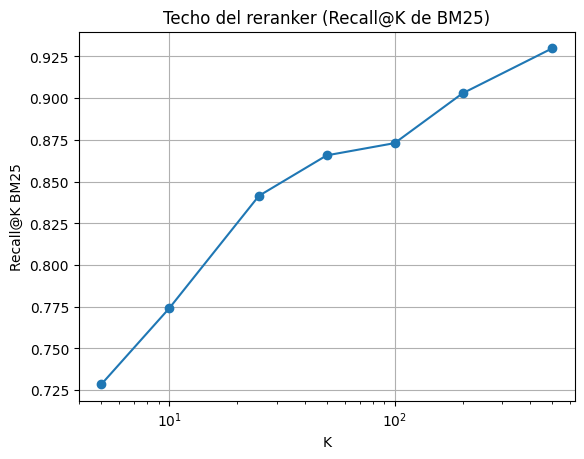

In [21]:
import matplotlib.pyplot as plt

Ks = [5, 10, 25, 50, 100, 200, 500]
recalls = []
for K in Ks:
    run_K = {}
    for qid, qtext in zip(df_queries["query_id"], df_queries["query"]):
        scores = bm25.get_scores(tokenize(qtext))
        top = np.argsort(scores)[::-1][:K]
        run_K[qid] = {doc_ids[i]: float(scores[i]) for i in top}
    ev = pytrec_eval.RelevanceEvaluator(qrels, {f"recall_{K}"})
    r = ev.evaluate(run_K)
    recalls.append(np.mean([x[f"recall_{K}"] for x in r.values()]))

plt.plot(Ks, recalls, marker="o")
plt.xlabel("K"); plt.ylabel("Recall@K BM25"); plt.xscale("log"); plt.grid()
plt.title("Techo del reranker (Recall@K de BM25)")
plt.show()

La curva logaritmica demuestra empiricamente que el re-ranking depende criticamente de la Etapa 1 de las diapositivas. A medida que aumentamos el valor de K, el Recall a K crece casi de forma logaritmica.
Si los documentos relevantes no superan el filtro rapido de BM25, es decir, no estan en ese primer grupo de candidatos, el modelo neuronal jamas podra ponerlos en el top 10. Por lo tanto, elegir el parametro K requiere un delicado equilibrio entre maximizar el Recall y no saturar el costo computacional de la Etapa 2.

2. Que pasa si aplico cross-encoder directamente sobre todo el corpus

In [22]:
import time

q_sample = df_queries["query"].iloc[0]
cands = list(bm25_run[df_queries["query_id"].iloc[0]].keys())

t0 = time.time()
bm25.get_scores(tokenize(q_sample))
t_bm25 = time.time() - t0

t0 = time.time()
ce_model.predict([(q_sample, doc_lookup[d]) for d in cands], show_progress_bar=False)
t_ce_100 = time.time() - t0

t_ce_full = t_ce_100 * (len(doc_ids) / 100)

print(f"BM25 sobre 5183 docs:        {t_bm25*1000:.1f} ms")
print(f"CE sobre 100 candidatos:     {t_ce_100*1000:.1f} ms")
print(f"CE sobre 5183 (extrapolado): {t_ce_full:.1f} s")
print(f"Speedup pipeline 2-etapas:   {t_ce_full/(t_bm25+t_ce_100):.0f}x")

BM25 sobre 5183 docs:        19.5 ms
CE sobre 100 candidatos:     493.4 ms
CE sobre 5183 (extrapolado): 25.6 s
Speedup pipeline 2-etapas:   50x


El modelo Cross-Encoder ejecuta atencion cruzada completa entre todos los tokens de la consulta y el documento, lo cual lo hace altamente preciso pero computacionalmente prohibitivo para corpus masivos.
Intentar aplicar el Cross-Encoder sobre los 5183 documentos directamente elevaria la latencia a niveles inaceptables para un sistema real. BM25 actua como un atajo: descartamos masivamente lo irrelevante a un costo de milisegundos para invertir los recursos pesados solo en el subconjunto mas prometedor

3. El rerank ayuda a todas las queries por igual o hay queries donde si empeora el ranking?
Si empeora algunas, ¿hay un patrón?

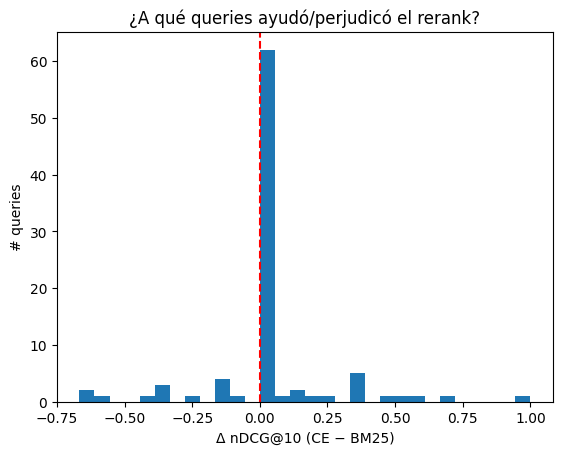

Mejoró: 15 | Empeoró: 13 | Igual: 62


In [24]:
delta = []
for qid in test_qids:
    if qid not in qrels: continue
    ev = pytrec_eval.RelevanceEvaluator({qid: qrels[qid]}, {"ndcg_cut_10"})
    n_bm25 = ev.evaluate({qid: bm25_run[qid]})[qid]["ndcg_cut_10"]
    n_ce   = ev.evaluate({qid: ce_run[qid]})[qid]["ndcg_cut_10"]
    delta.append(n_ce - n_bm25)

plt.hist(delta, bins=30)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Δ nDCG@10 (CE − BM25)"); plt.ylabel("# queries")
plt.title("¿A qué queries ayudó/perjudicó el rerank?")
plt.show()

print(f"Mejoró: {sum(d>0 for d in delta)} | Empeoró: {sum(d<0 for d in delta)} | Igual: {sum(d==0 for d in delta)}")

Aunque el re-ranking genera un impacto neto altamente positivo, como se ve en la barra central alta y las de la derecha, existe un grupo de consultas que fueron penalizadas del lado izquierdo. Esto ocurre tipicamente cuando se busca un termino tecnico exacto, como un codigo de gen o un acronimo. Mientras BM25 premia la exactitud de las palabras, el Cross-Encoder puede forzar coincidencias por significado semantico donde solo importaba la palabra exacta, empujando hacia abajo el documento correcto